In [ ]:
### https://medium.com/data-science/graph-convolutional-networks-introduction-to-gnns-24b3f60d6c95

In [ ]:
### figuring thisngs out 

In [1]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from torch.nn import Linear
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

In [3]:
# PyG's built-in KarateClub dataset: 34 nodes, 4 ground-truth groups (y)
dataset = KarateClub()
print(dataset)
print('------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

KarateClub()
------------
Number of graphs: 1
Number of features: 34
Number of classes: 4


In [12]:
data = dataset[0]
print(f'\nGraph: {data}')
print(f'x = {data.x.shape}')          # [34, 34] identity matrix
print(f'edge_index = {data.edge_index.shape}')  # [2, 156] edge list; two parallel arrays (source nodes, destination nodes)
print(f'y = {data.y.shape}')          # [34] ground-truth group per node
print(data.y)
print(f'train_mask = {data.train_mask.shape}')
print(data.train_mask)

print(f'\nEdges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')


Graph: Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
x = torch.Size([34, 34])
edge_index = torch.Size([2, 156])
y = torch.Size([34])
tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])
train_mask = torch.Size([34])
tensor([ True, False, False, False,  True, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])

Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


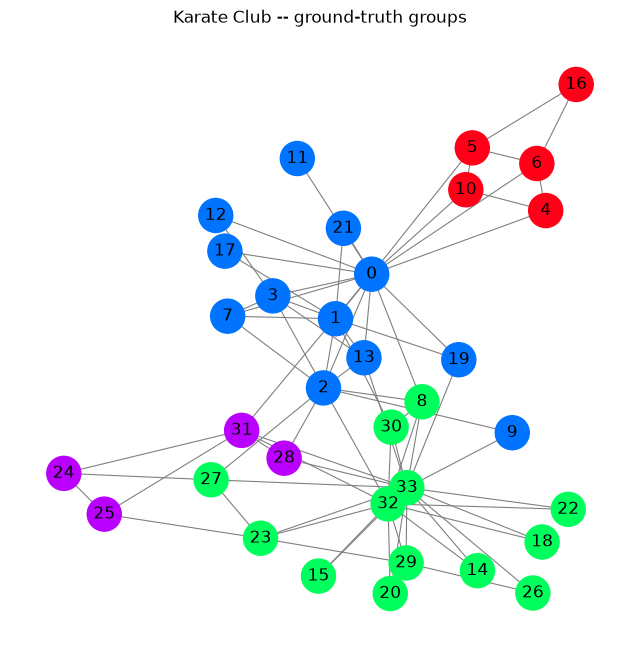

In [10]:
# --- Visualize the ground-truth groups ---
G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(8, 8))
plt.axis('off')
nx.draw_networkx(
    G,
    pos=nx.spring_layout(G, seed=0),
    with_labels=True,
    node_size=600,
    node_color=data.y,
    cmap="hsv",
    vmin=-2,
    vmax=3,
    width=0.8,
    edge_color="grey",
    font_size=12,
)
plt.title("Karate Club -- ground-truth groups")
plt.show()

In [7]:
# One GCNConv layer (34 features -> 3-dim embedding), ReLU, then a plain
# linear layer mapping the 3-dim embedding to 4 class scores.
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn = GCNConv(dataset.num_features, 3)
        self.out = Linear(3, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.gcn(x, edge_index).relu()  # the embedding (3-dim)
        z = self.out(h)                      # class scores (4-dim)
        return h, z


model = GCN()
print(model)

GCN(
  (gcn): GCNConv(34, 3)
  (out): Linear(in_features=3, out_features=4, bias=True)
)


Epoch   0 | Loss: 1.33 | Acc: 35.29%
Epoch  10 | Loss: 1.20 | Acc: 67.65%
Epoch  20 | Loss: 0.99 | Acc: 70.59%
Epoch  30 | Loss: 0.72 | Acc: 73.53%
Epoch  40 | Loss: 0.47 | Acc: 73.53%
Epoch  50 | Loss: 0.28 | Acc: 88.24%
Epoch  60 | Loss: 0.17 | Acc: 100.00%
Epoch  70 | Loss: 0.11 | Acc: 100.00%
Epoch  80 | Loss: 0.07 | Acc: 100.00%
Epoch  90 | Loss: 0.05 | Acc: 100.00%
Epoch 100 | Loss: 0.04 | Acc: 100.00%
Epoch 110 | Loss: 0.03 | Acc: 100.00%
Epoch 120 | Loss: 0.02 | Acc: 100.00%
Epoch 130 | Loss: 0.02 | Acc: 100.00%
Epoch 140 | Loss: 0.02 | Acc: 100.00%
Epoch 150 | Loss: 0.01 | Acc: 100.00%
Epoch 160 | Loss: 0.01 | Acc: 100.00%
Epoch 170 | Loss: 0.01 | Acc: 100.00%
Epoch 180 | Loss: 0.01 | Acc: 100.00%
Epoch 190 | Loss: 0.01 | Acc: 100.00%
Epoch 200 | Loss: 0.01 | Acc: 100.00%

Final embeddings = torch.Size([34, 3])
tensor([[0.0000e+00, 2.6300e-01, 2.2772e+00],
        [0.0000e+00, 0.0000e+00, 2.8873e+00],
        [1.0024e+00, 2.2243e-01, 2.3258e+00],
        [0.0000e+00, 0.0000e+0

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/karate_embeddings_3d.png'

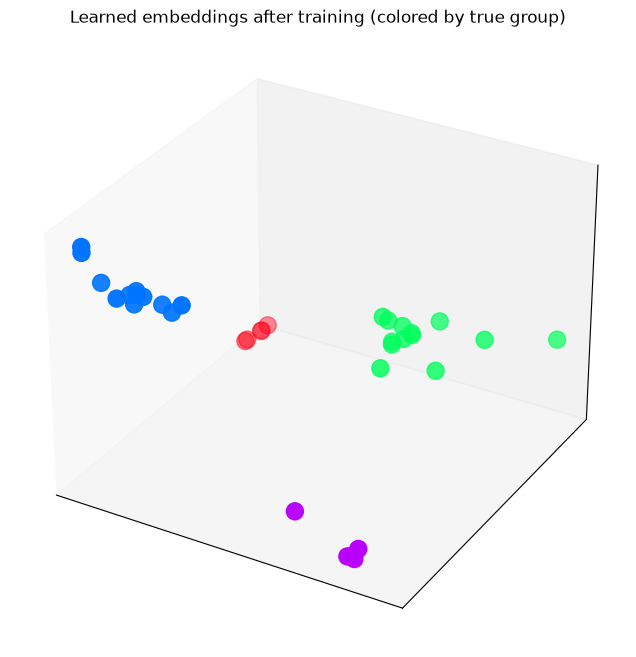

In [8]:
# training
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)


def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)


embeddings = []
losses = []
accuracies = []
outputs = []

for epoch in range(201):
    optimizer.zero_grad()

    h, z = model(data.x, data.edge_index)
    loss = criterion(z, data.y)          # compares predictions to ground truth
    acc = accuracy(z.argmax(dim=1), data.y)

    loss.backward()
    optimizer.step()

    embeddings.append(h)
    losses.append(loss)
    accuracies.append(acc)
    outputs.append(z.argmax(dim=1))

    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%')


# --- Final embeddings ---
print(f'\nFinal embeddings = {h.shape}')   # [34, 3]
print(h)


# --- Plot final embeddings in 3D, colored by ground-truth group ---
embed = h.detach().cpu().numpy()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.patch.set_alpha(0)
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2],
           s=150, c=data.y, cmap="hsv", vmin=-2, vmax=3)
plt.title("Learned embeddings after training (colored by true group)")
plt.savefig("/mnt/user-data/outputs/karate_embeddings_3d.png", dpi=120)
plt.show()

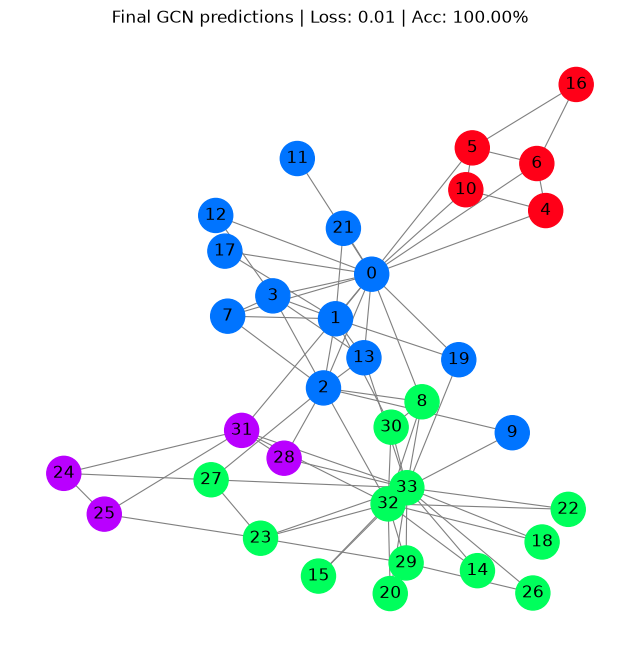

In [11]:
# --- Final predicted classification, plotted on the graph ---
plt.figure(figsize=(8, 8))
plt.axis('off')
nx.draw_networkx(
    G,
    pos=nx.spring_layout(G, seed=0),
    with_labels=True,
    node_size=600,
    node_color=outputs[-1],
    cmap="hsv",
    vmin=-2,
    vmax=3,
    width=0.8,
    edge_color="grey",
    font_size=12,
)
plt.title(f"Final GCN predictions | Loss: {losses[-1]:.2f} | Acc: {accuracies[-1]*100:.2f}%")
plt.show()